<a href="https://colab.research.google.com/github/kavee2002bc/Diabetic-Retinopathy-Detection-System-DL/blob/mobilenet-Piyumi/05_MobileNetV2_DDR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!ls "/content/drive/MyDrive"

 campusID.jpg
'Cloud Computing'
'Colab Notebooks'
'Deep Learning'
'Gmail - SUCCESSFUL INTERBANK TRANSFER RECEIVER.PDF'
'IMG-20241218-WA0028 (1).jpg'
 IMG-20241218-WA0028.jpg
'my part is contact us page, customise order page... (1).gsheet'
'my part is contact us page, customise order page... (2).gsheet'
'my part is contact us page, customise order page....gsheet'
'PiyumiRanaweera (1).pdf'
 Piyumi_Ranaweera_CV.pdf
 PiyumiRanaweera.pdf
 Receipt.jpg
 Research
'Untitled Diagram.drawio'
'Untitled spreadsheet.gsheet'


In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls "/content/drive/MyDrive/DL Project"

 ddr_common_split.csv  'DDR (Unzipped Files)'   MobileNetV2_Results


In [3]:
!find "/content/drive/MyDrive/DL Project/DDR (Unzipped Files)" -maxdepth 4 -type d

/content/drive/MyDrive/DL Project/DDR (Unzipped Files)
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading


In [4]:
!find "/content/drive/MyDrive/DL Project/DDR (Unzipped Files)" -type f | head -20

/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading/007-0043-000.jpg
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading/007-0033-000.jpg
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading/007-0055-000.jpg
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading/007-0052-000.jpg
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading/007-0067-000.jpg
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading/007-0071-000.jpg
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading/007-0050-000.jpg
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading/007-0022-000.jpg
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading/007-0041-000.jpg
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading/007-0060-000.jpg
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_gr

In [5]:
SPLIT_CSV = "/content/drive/MyDrive/DL Project/ddr_common_split.csv"

In [6]:
import pandas as pd

df = pd.read_csv(SPLIT_CSV)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

Shape: (12522, 5)
Columns: ['id_code', 'diagnosis', 'filepath', 'exists', 'split']
                 id_code  diagnosis  \
0  20170209143259326.jpg          0   
1       007-3253-100.jpg          1   
2       007-6141-300.jpg          2   
3       007-3697-200.jpg          2   
4       007-7323-601.jpg          0   

                                            filepath  exists  split  
0  /content/DDR/DR_grading/DR_grading/20170209143...    True  train  
1  /content/DDR/DR_grading/DR_grading/007-3253-10...    True  train  
2  /content/DDR/DR_grading/DR_grading/007-6141-30...    True  train  
3  /content/DDR/DR_grading/DR_grading/007-3697-20...    True  train  
4  /content/DDR/DR_grading/DR_grading/007-7323-60...    True  train  


In [7]:
print(df["split"].value_counts())

split
train         8765
test          1879
validation    1878
Name: count, dtype: int64


In [8]:
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 8765
Validation: 1878
Test: 1879


In [9]:
import os
import pandas as pd

IMAGE_DIR = "/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading"

SPLIT_CSV = "/content/drive/MyDrive/DL Project/ddr_common_split.csv"

print("Image folder exists:", os.path.exists(IMAGE_DIR))
print("CSV exists:", os.path.exists(SPLIT_CSV))

Image folder exists: True
CSV exists: True


In [10]:
df = pd.read_csv(SPLIT_CSV)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

df.head()

Shape: (12522, 5)
Columns: ['id_code', 'diagnosis', 'filepath', 'exists', 'split']


,id_code,diagnosis,filepath,exists,split
0,20170209143259326.jpg,0,/content/DDR/DR_grading/DR_grading/20170209143...,True,train
1,007-3253-100.jpg,1,/content/DDR/DR_grading/DR_grading/007-3253-10...,True,train
2,007-6141-300.jpg,2,/content/DDR/DR_grading/DR_grading/007-6141-30...,True,train
3,007-3697-200.jpg,2,/content/DDR/DR_grading/DR_grading/007-3697-20...,True,train
4,007-7323-601.jpg,0,/content/DDR/DR_grading/DR_grading/007-7323-60...,True,train


In [11]:
df["filepath"] = df["id_code"].apply(
    lambda x: os.path.join(IMAGE_DIR, x)
)

In [12]:
df[["id_code", "diagnosis", "split", "filepath"]].head()

,id_code,diagnosis,split,filepath
0,20170209143259326.jpg,0,train,/content/drive/MyDrive/DL Project/DDR (Unzippe...
1,007-3253-100.jpg,1,train,/content/drive/MyDrive/DL Project/DDR (Unzippe...
2,007-6141-300.jpg,2,train,/content/drive/MyDrive/DL Project/DDR (Unzippe...
3,007-3697-200.jpg,2,train,/content/drive/MyDrive/DL Project/DDR (Unzippe...
4,007-7323-601.jpg,0,train,/content/drive/MyDrive/DL Project/DDR (Unzippe...


In [13]:
df["exists"] = df["filepath"].apply(os.path.exists)

print("Total images :", len(df))
print("Found images :", df["exists"].sum())
print("Missing      :", (~df["exists"]).sum())

Total images : 12522
Found images : 84
Missing      : 12438


In [14]:
from pathlib import Path

IMAGE_DIR = "/content/drive/MyDrive/DL Project/DDR (Unzipped Files)"

image_files = list(Path(IMAGE_DIR).rglob("*.jpg"))

print("Total JPG images found:", len(image_files))
print("\nFirst 10 images:")

for p in image_files[:10]:
    print(p)

Total JPG images found: 84

First 10 images:
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading/007-0043-000.jpg
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading/007-0033-000.jpg
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading/007-0055-000.jpg
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading/007-0052-000.jpg
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading/007-0067-000.jpg
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading/007-0071-000.jpg
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading/007-0050-000.jpg
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading/007-0022-000.jpg
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading/007-0041-000.jpg
/content/drive/MyDrive/DL Project/DDR (Unzipped Files)/DR_grading/DR_grading/007-0060-000.jpg


In [15]:
print("CSV filenames:")
for x in df["id_code"].head(20):
    print(repr(x))

CSV filenames:
'20170209143259326.jpg'
'007-3253-100.jpg'
'007-6141-300.jpg'
'007-3697-200.jpg'
'007-7323-601.jpg'
'20170401085943596.jpg'
'007-3185-100.jpg'
'20170427191042581.jpg'
'20170614092847535.jpg'
'20170222092538402.jpg'
'007-5963-300.jpg'
'20170429205502213.jpg'
'20170323085247057.jpg'
'20170125091735546.jpg'
'20170328164726799.jpg'
'20170609184224697.jpg'
'20170606104243761.jpg'
'007-1248-000.jpg'
'20170427095240398.jpg'
'20170615112054786.jpg'


In [16]:
import os

IMAGE_ROOT = "/content/drive/MyDrive/DL Project/DDR (Unzipped Files)"

all_files = []

for root, dirs, files in os.walk(IMAGE_ROOT):
    for file in files:
        all_files.append(
            os.path.join(root, file)
        )

print("Total files:", len(all_files))

Total files: 85


In [17]:
from collections import Counter

extensions = Counter()

for file in all_files:
    ext = os.path.splitext(file)[1].lower()
    extensions[ext] += 1

print(extensions)

Counter({'.jpg': 84, '.csv': 1})


In [18]:
ZIP_PATH = "/content/drive/MyDrive/DL Project/DDR.zip"

!unzip -l "$ZIP_PATH" | grep -Ei '\.(jpg|jpeg|png)$' | wc -l

unzip:  cannot find or open /content/drive/MyDrive/DL Project/DDR.zip, /content/drive/MyDrive/DL Project/DDR.zip.zip or /content/drive/MyDrive/DL Project/DDR.zip.ZIP.
0


In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls -lh "/content/drive/MyDrive/DL Project"

total 3.0G
-rw------- 1 root root 1.1M Sep 23 04:54 ddr_common_split.csv
-r-------- 1 root root 3.0G Sep 23 04:29 DDR.zip
drwx------ 2 root root 4.0K Sep 23 06:56 MobileNetV2_Results


In [3]:
ZIP_PATH = "/content/drive/MyDrive/DL Project/DDR.zip"

import os

print("ZIP exists:", os.path.exists(ZIP_PATH))

ZIP exists: True


In [4]:
!cp "$ZIP_PATH" /content/DDR.zip

In [5]:
!ls -lh /content/DDR.zip

-r-------- 1 root root 3.0G Sep 24 03:54 /content/DDR.zip


In [6]:
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   54G   60G  48% /


In [7]:
!mkdir -p /content/DDR

In [8]:
!unzip -q /content/DDR.zip -d /content/DDR

In [9]:
!find /content/DDR -maxdepth 3 -type d

/content/DDR
/content/DDR/DR_grading
/content/DDR/DR_grading/DR_grading


In [10]:
!find /content/DDR -type f | head -20

/content/DDR/DR_grading.csv
/content/DDR/DR_grading/DR_grading/007-0004-000.jpg
/content/DDR/DR_grading/DR_grading/007-0007-000.jpg
/content/DDR/DR_grading/DR_grading/007-0008-000.jpg
/content/DDR/DR_grading/DR_grading/007-0009-000.jpg
/content/DDR/DR_grading/DR_grading/007-0011-000.jpg
/content/DDR/DR_grading/DR_grading/007-0013-000.jpg
/content/DDR/DR_grading/DR_grading/007-0022-000.jpg
/content/DDR/DR_grading/DR_grading/007-0023-000.jpg
/content/DDR/DR_grading/DR_grading/007-0024-000.jpg
/content/DDR/DR_grading/DR_grading/007-0025-000.jpg
/content/DDR/DR_grading/DR_grading/007-0026-000.jpg
/content/DDR/DR_grading/DR_grading/007-0028-000.jpg
/content/DDR/DR_grading/DR_grading/007-0029-000.jpg
/content/DDR/DR_grading/DR_grading/007-0030-000.jpg
/content/DDR/DR_grading/DR_grading/007-0031-000.jpg
/content/DDR/DR_grading/DR_grading/007-0032-000.jpg
/content/DDR/DR_grading/DR_grading/007-0033-000.jpg
/content/DDR/DR_grading/DR_grading/007-0034-000.jpg
/content/DDR/DR_grading/DR_grading/0

In [11]:
from pathlib import Path

image_files = []

for ext in ["*.jpg", "*.jpeg", "*.JPG", "*.JPEG"]:
    image_files.extend(Path("/content/DDR").rglob(ext))

print("Total image files:", len(image_files))

Total image files: 12524


In [12]:
import pandas as pd

SPLIT_CSV = "/content/drive/MyDrive/DL Project/ddr_common_split.csv"

df = pd.read_csv(SPLIT_CSV)

print("Rows:", len(df))
print("Columns:", df.columns.tolist())

Rows: 12522
Columns: ['id_code', 'diagnosis', 'filepath', 'exists', 'split']


In [13]:
image_map = {
    p.name.strip().lower(): str(p)
    for p in image_files
}

print("Mapped images:", len(image_map))

Mapped images: 12524


In [14]:
df["id_clean"] = (
    df["id_code"]
    .astype(str)
    .str.strip()
    .str.lower()
)

In [15]:
df["filepath"] = df["id_clean"].map(image_map)

In [16]:
df["exists"] = df["filepath"].notna()

print("Total CSV records :", len(df))
print("Images matched    :", df["exists"].sum())
print("Missing images    :", (~df["exists"]).sum())

Total CSV records : 12522
Images matched    : 12522
Missing images    : 0


Filename: 20170209143259326.jpg
Diagnosis: 0
Image size: (512, 512)


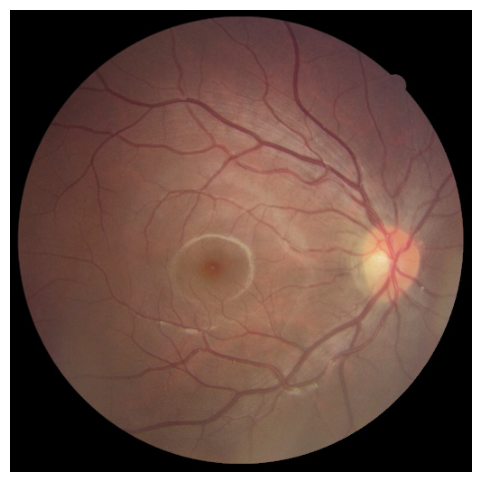

In [17]:
from PIL import Image
import matplotlib.pyplot as plt

sample = df[df["exists"]].iloc[0]

img = Image.open(sample["filepath"])

print("Filename:", sample["id_code"])
print("Diagnosis:", sample["diagnosis"])
print("Image size:", img.size)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [18]:
print(df["split"].value_counts())

split
train         8765
test          1879
validation    1878
Name: count, dtype: int64


In [19]:
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 8765
Validation: 1878
Test: 1879


In [20]:
!mkdir -p /content/DDR

In [21]:
!unzip -q /content/DDR.zip -d /content/DDR

replace /content/DDR/DR_grading.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [22]:
!rm -rf /content/DDR

In [23]:
!mkdir -p /content/DDR


In [24]:
!unzip -qo /content/DDR.zip -d /content/DDR

In [25]:
from pathlib import Path

image_files = []

for ext in ["*.jpg", "*.jpeg", "*.JPG", "*.JPEG"]:
    image_files.extend(
        Path("/content/DDR").rglob(ext)
    )

print("Total image files:", len(image_files))

Total image files: 12524


In [26]:
!find /content/DDR -maxdepth 3 -type d

/content/DDR
/content/DDR/DR_grading
/content/DDR/DR_grading/DR_grading


In [27]:
!find /content/DDR -type f | head -20

/content/DDR/DR_grading.csv
/content/DDR/DR_grading/DR_grading/007-0004-000.jpg
/content/DDR/DR_grading/DR_grading/007-0007-000.jpg
/content/DDR/DR_grading/DR_grading/007-0008-000.jpg
/content/DDR/DR_grading/DR_grading/007-0009-000.jpg
/content/DDR/DR_grading/DR_grading/007-0011-000.jpg
/content/DDR/DR_grading/DR_grading/007-0013-000.jpg
/content/DDR/DR_grading/DR_grading/007-0022-000.jpg
/content/DDR/DR_grading/DR_grading/007-0023-000.jpg
/content/DDR/DR_grading/DR_grading/007-0024-000.jpg
/content/DDR/DR_grading/DR_grading/007-0025-000.jpg
/content/DDR/DR_grading/DR_grading/007-0026-000.jpg
/content/DDR/DR_grading/DR_grading/007-0028-000.jpg
/content/DDR/DR_grading/DR_grading/007-0029-000.jpg
/content/DDR/DR_grading/DR_grading/007-0030-000.jpg
/content/DDR/DR_grading/DR_grading/007-0031-000.jpg
/content/DDR/DR_grading/DR_grading/007-0032-000.jpg
/content/DDR/DR_grading/DR_grading/007-0033-000.jpg
/content/DDR/DR_grading/DR_grading/007-0034-000.jpg
/content/DDR/DR_grading/DR_grading/0

In [28]:
!unzip -l /content/DDR.zip | grep -Ei '\.(jpg|jpeg)$' | wc -l

12524


In [29]:
import pandas as pd
import os

SPLIT_CSV = "/content/drive/MyDrive/DL Project/ddr_common_split.csv"

df = pd.read_csv(SPLIT_CSV)

print("CSV rows:", len(df))
print("Columns:", df.columns.tolist())
print(df.head())

CSV rows: 12522
Columns: ['id_code', 'diagnosis', 'filepath', 'exists', 'split']
                 id_code  diagnosis  \
0  20170209143259326.jpg          0   
1       007-3253-100.jpg          1   
2       007-6141-300.jpg          2   
3       007-3697-200.jpg          2   
4       007-7323-601.jpg          0   

                                            filepath  exists  split  
0  /content/DDR/DR_grading/DR_grading/20170209143...    True  train  
1  /content/DDR/DR_grading/DR_grading/007-3253-10...    True  train  
2  /content/DDR/DR_grading/DR_grading/007-6141-30...    True  train  
3  /content/DDR/DR_grading/DR_grading/007-3697-20...    True  train  
4  /content/DDR/DR_grading/DR_grading/007-7323-60...    True  train  


In [30]:
IMAGE_DIR = "/content/DDR/DR_grading/DR_grading"

print(os.path.exists(IMAGE_DIR))

True


In [31]:
from pathlib import Path

image_files = []

for ext in ["*.jpg", "*.jpeg", "*.JPG", "*.JPEG"]:
    image_files.extend(
        Path("/content/DDR").rglob(ext)
    )

print("Total image files:", len(image_files))

Total image files: 12524


In [32]:
image_map = {
    p.name.strip().lower(): str(p)
    for p in image_files
}

print("Mapped filenames:", len(image_map))

Mapped filenames: 12524


In [33]:
df["id_clean"] = (
    df["id_code"]
    .astype(str)
    .str.strip()
    .str.lower()
)

In [34]:
df["filepath"] = df["id_clean"].map(image_map)

In [35]:
df["exists"] = df["filepath"].notna()

print("CSV records     :", len(df))
print("Images matched  :", df["exists"].sum())
print("Missing images  :", (~df["exists"]).sum())

CSV records     : 12522
Images matched  : 12522
Missing images  : 0


In [36]:
csv_filenames = set(
    df["id_clean"]
)

extra_images = [
    str(p)
    for p in image_files
    if p.name.strip().lower()
    not in csv_filenames
]

print("Extra images:", len(extra_images))

for p in extra_images:
    print(p)

Extra images: 2
/content/DDR/DR_grading/DR_grading/007-7447-601.jpg
/content/DDR/DR_grading/DR_grading/007-7449-601.jpg


In [37]:
df = df[df["exists"]].copy()

print(len(df))

12522


In [38]:
print(df["split"].value_counts())

split
train         8765
test          1879
validation    1878
Name: count, dtype: int64


In [39]:
train_df = df[
    df["split"] == "train"
].copy()

val_df = df[
    df["split"] == "validation"
].copy()

test_df = df[
    df["split"] == "test"
].copy()

print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

Train      : 8765
Validation : 1878
Test       : 1879


Filename : 20170209143259326.jpg
Diagnosis: 0
Size     : (512, 512)


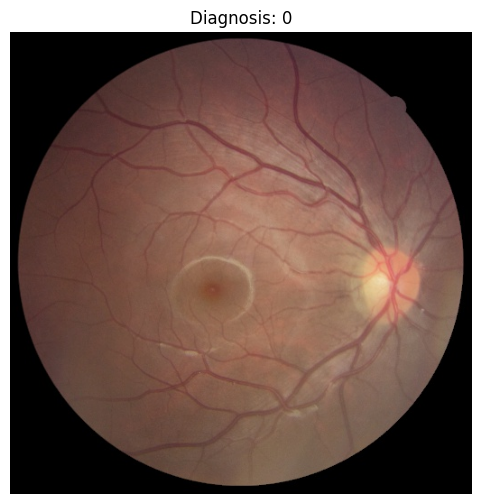

In [40]:
from PIL import Image
import matplotlib.pyplot as plt

sample = train_df.iloc[0]

img = Image.open(
    sample["filepath"]
)

print("Filename :", sample["id_code"])
print("Diagnosis:", sample["diagnosis"])
print("Size     :", img.size)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Diagnosis: {sample['diagnosis']}"
)
plt.show()

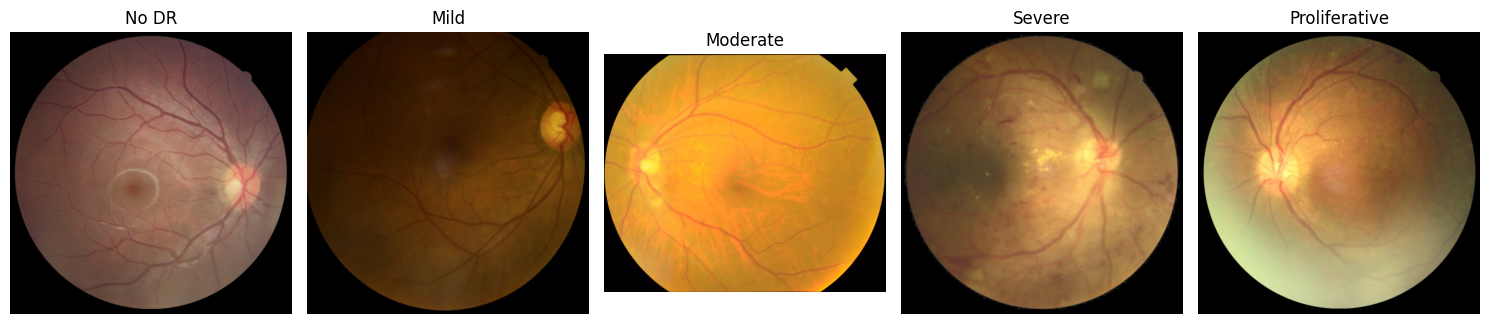

In [41]:
class_names = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative"
}

plt.figure(figsize=(15,4))

for label in range(5):

    sample = train_df[
        train_df["diagnosis"] == label
    ].iloc[0]

    img = Image.open(
        sample["filepath"]
    )

    plt.subplot(1,5,label+1)
    plt.imshow(img)
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [42]:
print(
    train_df["diagnosis"]
    .value_counts()
    .sort_index()
)

diagnosis
0    4386
1     441
2    3134
3     165
4     639
Name: count, dtype: int64


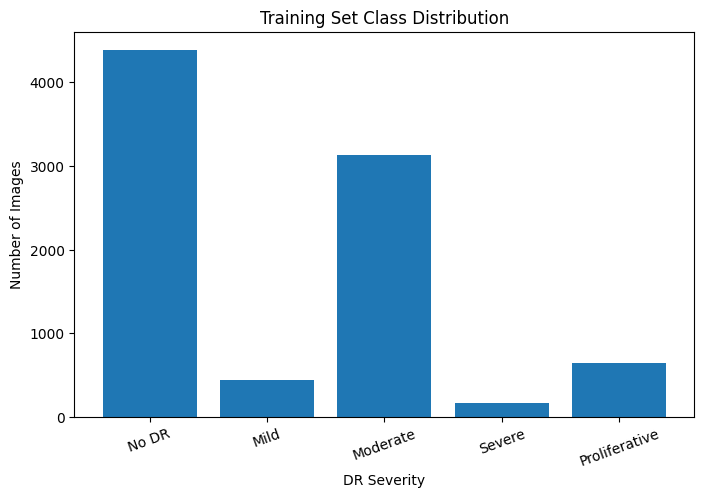

In [43]:
counts = (
    train_df["diagnosis"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,5))

plt.bar(
    [class_names[i] for i in counts.index],
    counts.values
)

plt.xlabel("DR Severity")
plt.ylabel("Number of Images")
plt.title(
    "Training Set Class Distribution"
)

plt.xticks(rotation=20)
plt.show()

In [44]:
print("CSV records     :", len(df))
print("Images matched  :", df["exists"].sum())
print("Missing images  :", (~df["exists"]).sum())

CSV records     : 12522
Images matched  : 12522
Missing images  : 0


In [45]:
print("Extra images:", len(extra_images))

Extra images: 2


In [46]:
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 8765
Validation: 1878
Test: 1879


In [47]:
import tensorflow as tf
import numpy as np
import random

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 5
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [48]:
def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label

In [49]:
def create_dataset(dataframe, training=False):

    paths = dataframe["filepath"].values

    labels = dataframe["diagnosis"].values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    ds = ds.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        ds = ds.shuffle(
            buffer_size=2000,
            seed=SEED
        )

    ds = ds.batch(BATCH_SIZE)

    ds = ds.prefetch(
        tf.data.AUTOTUNE
    )

    return ds

In [50]:
train_dataset = create_dataset(
    train_df,
    training=True
)

val_dataset = create_dataset(
    val_df
)

test_dataset = create_dataset(
    test_df
)

In [51]:
for images, labels in train_dataset.take(1):

    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


In [52]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([

    layers.RandomFlip(
        "horizontal"
    ),

    layers.RandomRotation(
        0.05
    ),

    layers.RandomZoom(
        0.10
    ),

    layers.RandomContrast(
        0.10
    )
])

In [53]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1, 2, 3, 4])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["diagnosis"]
)

class_weights = dict(
    zip(classes, weights)
)

print(class_weights)

{np.int64(0): np.float64(0.3996808025535796), np.int64(1): np.float64(3.9750566893424035), np.int64(2): np.float64(0.5593490746649649), np.int64(3): np.float64(10.624242424242425), np.int64(4): np.float64(2.7433489827856024)}


In [54]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model

In [55]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [56]:
base_model.trainable = False

In [57]:
inputs = layers.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.4)(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    5,
    activation="softmax"
)(x)

mobilenet_model = Model(
    inputs,
    outputs,
    name="MobileNetV2_DR"
)

In [58]:
mobilenet_model.summary()

Model: "MobileNetV2_DR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [59]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [60]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [61]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

RESULT_DIR = "/content/drive/MyDrive/DL Project/MobileNetV2_Results"
!mkdir -p "{RESULT_DIR}"

callbacks_stage1 = [

    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        f"{RESULT_DIR}/mobilenetv2_stage1_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

NameError: name 'RESULT_DIR' is not defined

In [62]:
import os

RESULT_DIR = "/content/drive/MyDrive/DL Project/MobileNetV2_Results"

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

print("Result folder:", RESULT_DIR)
print("Folder ready:", os.path.exists(RESULT_DIR))

Result folder: /content/drive/MyDrive/DL Project/MobileNetV2_Results
Folder ready: True


In [63]:
import os

RESULT_DIR = "/content/drive/MyDrive/DL Project/MobileNetV2_Results"

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

print("Result folder:", RESULT_DIR)
print("Folder ready:", os.path.exists(RESULT_DIR))

Result folder: /content/drive/MyDrive/DL Project/MobileNetV2_Results
Folder ready: True


In [64]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

callbacks_stage1 = [

    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        f"{RESULT_DIR}/mobilenetv2_stage1_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks created successfully.")

Callbacks created successfully.


In [65]:
import time

start_time = time.time()

history_stage1 = mobilenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks_stage1
)

end_time = time.time()

stage1_time = end_time - start_time

print(
    "Stage 1 training time:",
    round(stage1_time / 60, 2),
    "minutes"
)

Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.3468 - loss: 1.6705
Epoch 1: val_loss improved from None to 1.16268, saving model to /content/drive/MyDrive/DL Project/MobileNetV2_Results/mobilenetv2_stage1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DL Project/MobileNetV2_Results/mobilenetv2_stage1_best.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 103s 288ms/step - accuracy: 0.3847 - loss: 1.4429 - val_accuracy: 0.5644 - val_loss: 1.1627 - learning_rate: 0.0010
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.4363 - loss: 1.2736
Epoch 2: val_loss did not improve from 1.16268
274/274 ━━━━━━━━━━━━━━━━━━━━ 129s 267ms/step - accuracy: 0.4273 - loss: 1.2522 - val_accuracy: 0.3818 - val_loss: 1.2711 - learning_rate: 0.0010
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.4107 - loss: 1.2359
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_loss did not improve from 1.16268
274/274

In [66]:
import pandas as pd

pd.DataFrame(
    history_stage1.history
).to_csv(
    f"{RESULT_DIR}/stage1_history.csv",
    index=False
)

print("Stage 1 history saved.")

Stage 1 history saved.


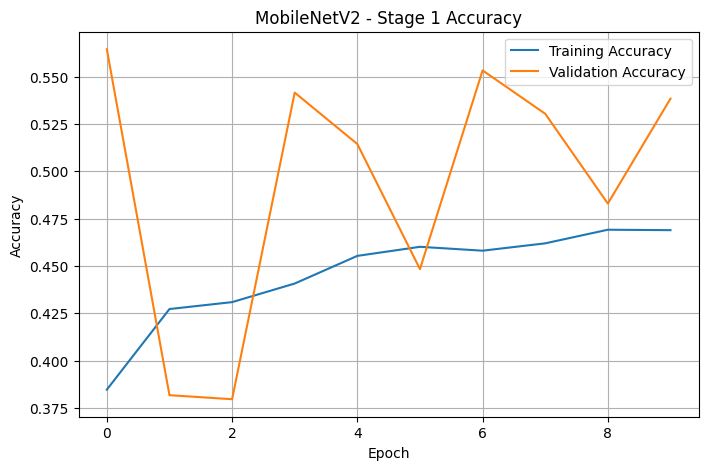

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history_stage1.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_stage1.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 - Stage 1 Accuracy")
plt.legend()
plt.grid()

plt.savefig(
    f"{RESULT_DIR}/stage1_accuracy.png",
    bbox_inches="tight"
)

plt.show()

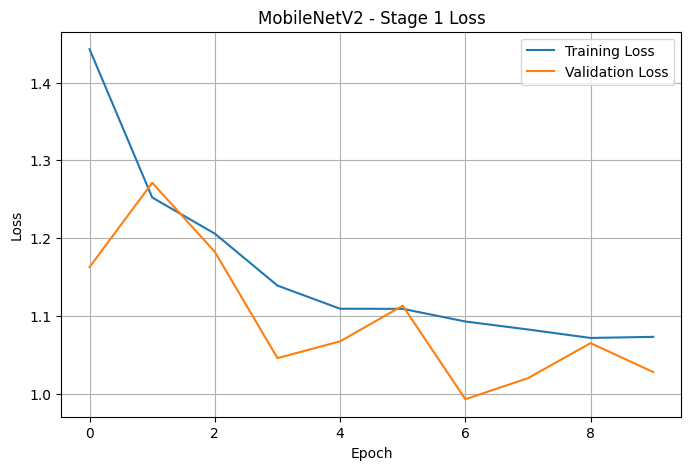

In [68]:
plt.figure(figsize=(8,5))

plt.plot(
    history_stage1.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_stage1.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 - Stage 1 Loss")
plt.legend()
plt.grid()

plt.savefig(
    f"{RESULT_DIR}/stage1_loss.png",
    bbox_inches="tight"
)

plt.show()

In [69]:
base_model.trainable = True

In [70]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [71]:
for layer in base_model.layers:

    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = False

In [72]:
trainable_layers = [
    layer.name
    for layer in mobilenet_model.layers
    if layer.trainable
]

print("Number of trainable layers:",
      len(trainable_layers))

print("\nTrainable layers:")
for layer in trainable_layers:
    print(layer)

Number of trainable layers: 8

Trainable layers:
input_layer_1
sequential
mobilenetv2_1.00_224
global_average_pooling2d
dropout
dense
dropout_1
dense_1


In [73]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [74]:
callbacks_stage2 = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        f"{RESULT_DIR}/mobilenetv2_final.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [75]:
import time

start_time = time.time()

history_stage2 = mobilenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks_stage2
)

end_time = time.time()

stage2_time = end_time - start_time

print(
    "Stage 2 training time:",
    round(stage2_time / 60, 2),
    "minutes"
)

Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.4888 - loss: 1.0918
Epoch 1: val_loss improved from None to 1.01538, saving model to /content/drive/MyDrive/DL Project/MobileNetV2_Results/mobilenetv2_final.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DL Project/MobileNetV2_Results/mobilenetv2_final.keras
274/274 ━━━━━━━━━━━━━━━━━━━━ 83s 232ms/step - accuracy: 0.4740 - loss: 1.0791 - val_accuracy: 0.5272 - val_loss: 1.0154 - learning_rate: 1.0000e-05
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.4717 - loss: 1.0677
Epoch 2: val_loss did not improve from 1.01538
274/274 ━━━━━━━━━━━━━━━━━━━━ 84s 256ms/step - accuracy: 0.4701 - loss: 1.0512 - val_accuracy: 0.5170 - val_loss: 1.0282 - learning_rate: 1.0000e-05
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.4828 - loss: 1.0183
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 3: val_loss did not improve from 1.01538
274/274 ━━━━━

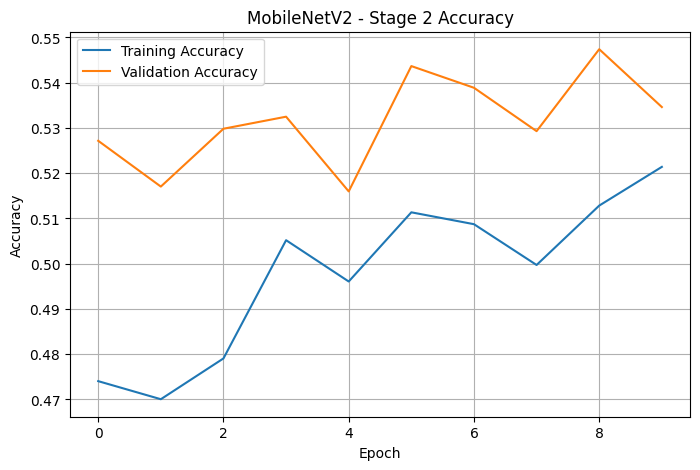

In [76]:
plt.figure(figsize=(8,5))

plt.plot(
    history_stage2.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_stage2.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 - Stage 2 Accuracy")
plt.legend()
plt.grid()

plt.savefig(
    f"{RESULT_DIR}/stage2_accuracy.png",
    bbox_inches="tight"
)

plt.show()

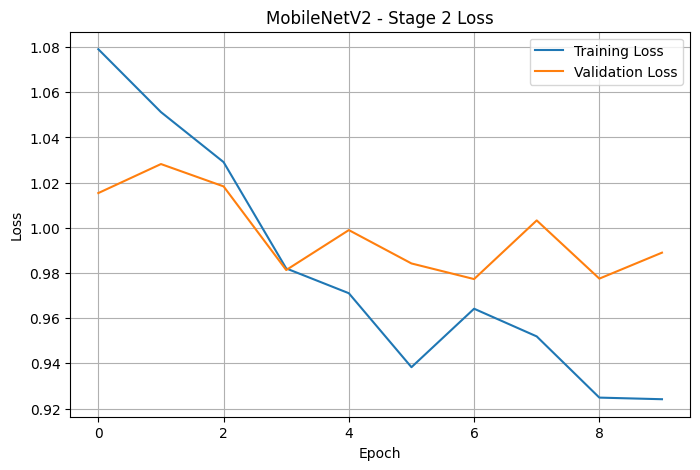

In [77]:
plt.figure(figsize=(8,5))

plt.plot(
    history_stage2.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_stage2.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 - Stage 2 Loss")
plt.legend()
plt.grid()

plt.savefig(
    f"{RESULT_DIR}/stage2_loss.png",
    bbox_inches="tight"
)

plt.show()

In [78]:
best_stage1_val_acc = max(
    history_stage1.history["val_accuracy"]
)

best_stage2_val_acc = max(
    history_stage2.history["val_accuracy"]
)

best_stage1_val_loss = min(
    history_stage1.history["val_loss"]
)

best_stage2_val_loss = min(
    history_stage2.history["val_loss"]
)

print("Stage 1 best validation accuracy:",
      best_stage1_val_acc)

print("Stage 2 best validation accuracy:",
      best_stage2_val_acc)

print("Stage 1 best validation loss:",
      best_stage1_val_loss)

print("Stage 2 best validation loss:",
      best_stage2_val_loss)

Stage 1 best validation accuracy: 0.5644302368164062
Stage 2 best validation accuracy: 0.5473908185958862
Stage 1 best validation loss: 0.9927480220794678
Stage 2 best validation loss: 0.977301836013794


In [79]:
def get_predictions(model, dataset):

    y_true = []
    y_prob = []

    for images, labels in dataset:

        probabilities = model.predict(
            images,
            verbose=0
        )

        y_true.extend(
            labels.numpy()
        )

        y_prob.extend(
            probabilities
        )

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    return y_true, y_pred, y_prob

In [80]:
val_true, val_pred, val_prob = get_predictions(
    mobilenet_model,
    val_dataset
)

In [81]:
from sklearn.metrics import f1_score

val_f1 = f1_score(
    val_true,
    val_pred,
    average="macro",
    zero_division=0
)

print("Validation Macro F1:", val_f1)

Validation Macro F1: 0.4431143478427364


In [82]:
test_loss, test_accuracy = mobilenet_model.evaluate(
    test_dataset
)

print("Final Test Loss:", test_loss)
print("Final Test Accuracy:", test_accuracy)

59/59 ━━━━━━━━━━━━━━━━━━━━ 13s 212ms/step - accuracy: 0.5338 - loss: 0.9794
Final Test Loss: 0.9794235229492188
Final Test Accuracy: 0.5337945818901062


In [83]:
y_true = []
y_prob = []

for images, labels in test_dataset:

    probabilities = mobilenet_model.predict(
        images,
        verbose=0
    )

    y_true.extend(
        labels.numpy()
    )

    y_prob.extend(
        probabilities
    )

y_true = np.array(y_true)
y_prob = np.array(y_prob)

y_pred = np.argmax(
    y_prob,
    axis=1
)

In [84]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    cohen_kappa_score
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

qwk = cohen_kappa_score(
    y_true,
    y_pred,
    weights="quadratic"
)

y_true_onehot = tf.keras.utils.to_categorical(
    y_true,
    num_classes=5
)

roc_auc = roc_auc_score(
    y_true_onehot,
    y_prob,
    multi_class="ovr",
    average="macro"
)

print("========== MobileNetV2 FINAL RESULTS ==========")
print("Accuracy        :", accuracy)
print("Macro Precision :", precision)
print("Macro Recall    :", recall)
print("Macro F1        :", f1)
print("ROC-AUC         :", roc_auc)
print("QWK             :", qwk)

========== MobileNetV2 FINAL RESULTS ==========
Accuracy        : 0.533794571580628
Macro Precision : 0.48142594364202135
Macro Recall    : 0.5922992447729045
Macro F1        : 0.4546698039180413
ROC-AUC         : 0.8624459693363409
QWK             : 0.6829998496231235


In [85]:
from sklearn.metrics import classification_report

class_names = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative"
]

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print(report)

               precision    recall  f1-score   support

        No DR       0.82      0.68      0.75       940
         Mild       0.10      0.61      0.18        95
     Moderate       0.72      0.27      0.40       672
       Severe       0.24      0.71      0.36        35
Proliferative       0.53      0.68      0.59       137

     accuracy                           0.53      1879
    macro avg       0.48      0.59      0.45      1879
 weighted avg       0.71      0.53      0.57      1879



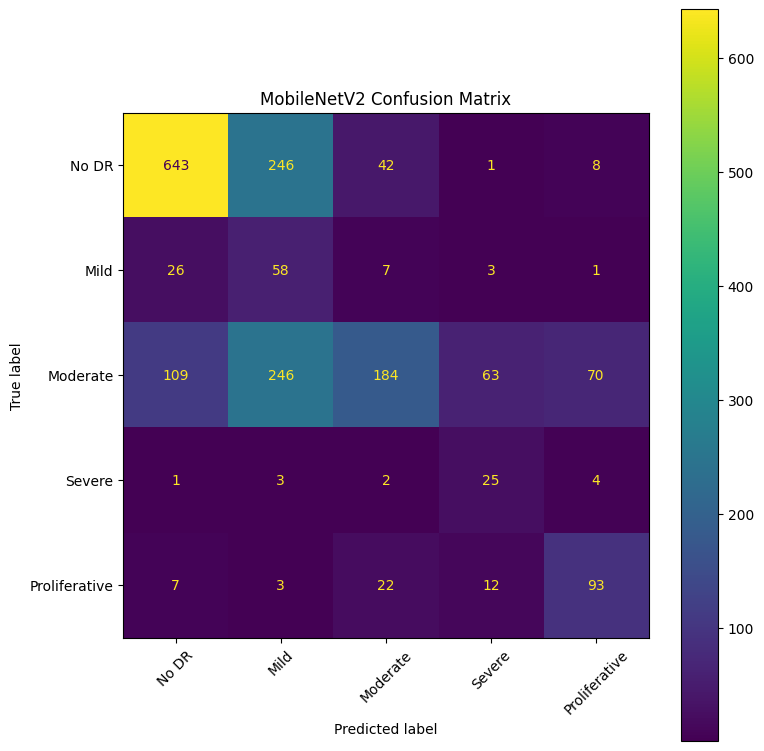

In [86]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title(
    "MobileNetV2 Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    f"{RESULT_DIR}/confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

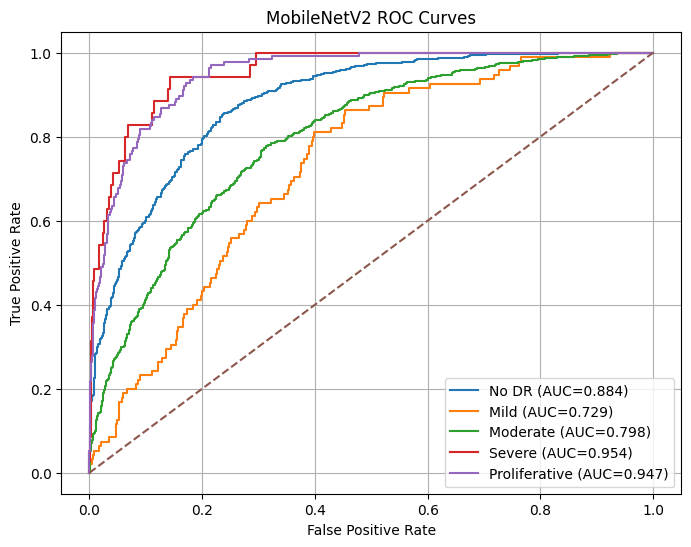

In [87]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(
    y_true,
    classes=[0,1,2,3,4]
)

plt.figure(figsize=(8,6))

for i in range(5):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    class_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC={class_auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "MobileNetV2 ROC Curves"
)

plt.legend()
plt.grid()

plt.savefig(
    f"{RESULT_DIR}/roc_curve.png",
    bbox_inches="tight"
)

plt.show()

In [88]:
wrong_indices = np.where(
    y_true != y_pred
)[0]

print(
    "Misclassified images:",
    len(wrong_indices)
)

Misclassified images: 876


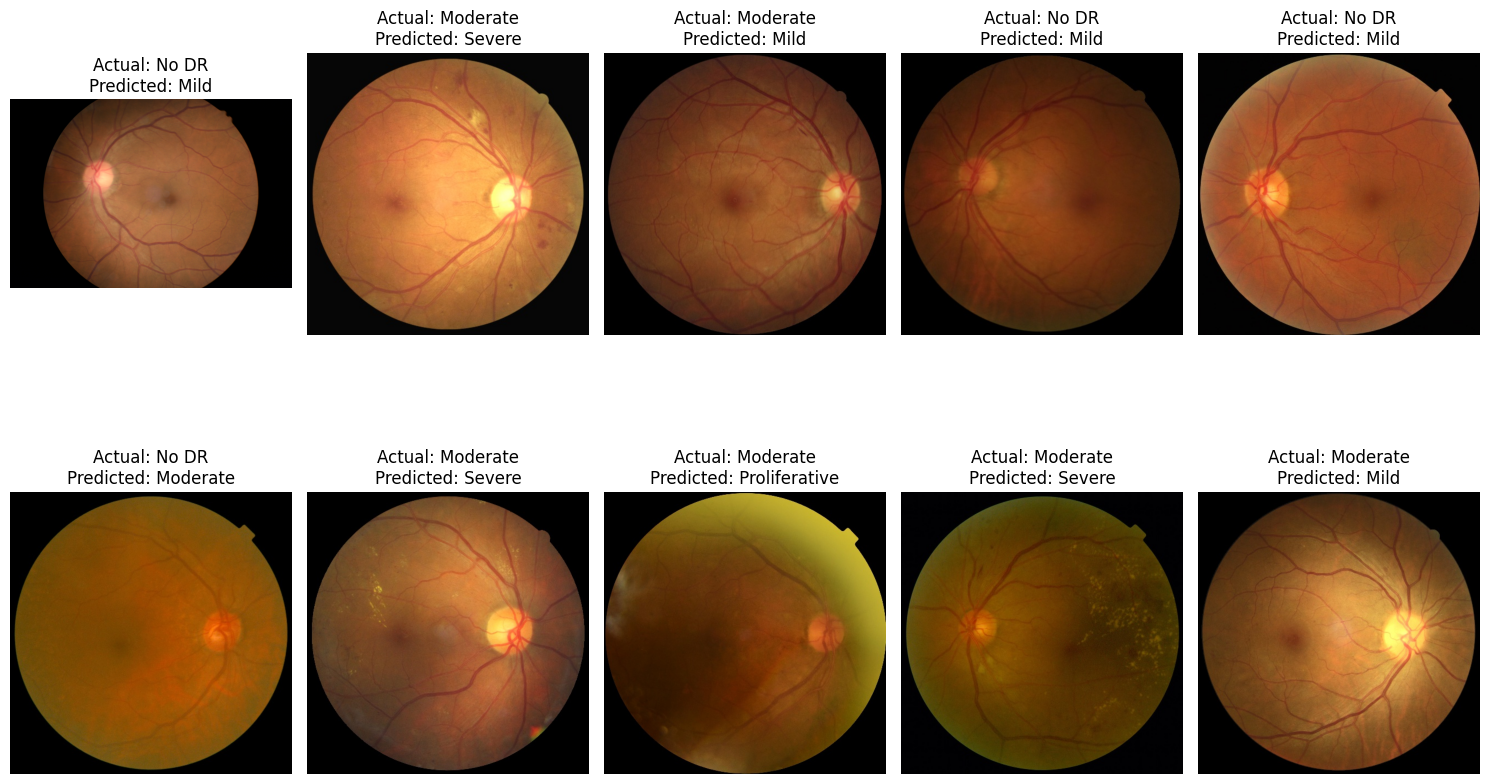

In [89]:
from PIL import Image

plt.figure(figsize=(15,10))

for i, idx in enumerate(
    wrong_indices[:10]
):

    image_path = test_df.iloc[idx]["filepath"]

    image = Image.open(
        image_path
    )

    actual = y_true[idx]
    predicted = y_pred[idx]

    plt.subplot(2,5,i+1)

    plt.imshow(image)

    plt.title(
        f"Actual: {class_names[actual]}\n"
        f"Predicted: {class_names[predicted]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    f"{RESULT_DIR}/misclassified_examples.png",
    bbox_inches="tight"
)

plt.show()

In [90]:
final_results = pd.DataFrame([{

    "Model": "MobileNetV2",

    "Accuracy": accuracy,

    "Macro Precision": precision,

    "Macro Recall": recall,

    "Macro F1": f1,

    "ROC-AUC": roc_auc,

    "QWK": qwk,

    "Parameters": mobilenet_model.count_params(),

    "Stage 1 Time (min)": stage1_time / 60,

    "Stage 2 Time (min)": stage2_time / 60
}])

final_results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,ROC-AUC,QWK,Parameters,Stage 1 Time (min),Stage 2 Time (min)
0,MobileNetV2,0.533795,0.481426,0.592299,0.45467,0.862446,0.683,2422597,14.270914,13.108391


In [91]:
final_results.to_csv(
    f"{RESULT_DIR}/mobilenetv2_metrics.csv",
    index=False
)

In [92]:
pd.DataFrame(
    history_stage2.history
).to_csv(
    f"{RESULT_DIR}/stage2_history.csv",
    index=False
)

In [93]:
mobilenet_model.save(
    f"{RESULT_DIR}/mobilenetv2_final.keras"
)

In [94]:
final_summary = pd.DataFrame([{
    "Model": "MobileNetV2",
    "Test Accuracy": accuracy,
    "Macro Precision": precision,
    "Macro Recall": recall,
    "Macro F1": f1,
    "ROC-AUC": roc_auc,
    "QWK": qwk,
    "Parameters": mobilenet_model.count_params(),
    "Stage 1 Time (min)": stage1_time / 60,
    "Stage 2 Time (min)": stage2_time / 60
}])

final_summary.to_csv(
    f"{RESULT_DIR}/MobileNetV2_Final_Summary.csv",
    index=False
)

final_summary

,Model,Test Accuracy,Macro Precision,Macro Recall,Macro F1,ROC-AUC,QWK,Parameters,Stage 1 Time (min),Stage 2 Time (min)
0,MobileNetV2,0.533795,0.481426,0.592299,0.45467,0.862446,0.683,2422597,14.270914,13.108391
